In [472]:
import pandas as pd
preprocessed_data = pd.read_csv("data/input_model.csv")
preprocessed_data

,country,year,adaptation_and_nature_solutions,climate_science_and_phenomena,energy_and_technology,extreme_weather_and_impacts,greenhouse_gases_and_emissions,policy_agreements_and_economics,total_sentences,climate_sentences_BERT,climate_sentence_ratio_BERT,renew_pct,log_gdp,vulnerability_score,Entity,share_co2,log_share_co2
0,AFG,1995,0.0,0.0,0.0,0.0,0.0,0.0,122.0,2.0,0.016393,31.8,NaN,0.648095,Afghanistan,0.007197,-4.934130
1,AFG,1996,0.0,0.0,0.0,0.0,0.0,0.0,86.0,1.0,0.011628,33.9,NaN,0.648263,Afghanistan,0.007157,-4.939635
2,AFG,1997,0.0,0.0,0.0,0.0,0.0,0.0,77.0,1.0,0.012987,36.4,NaN,0.648422,Afghanistan,0.007112,-4.946000
3,AFG,1998,0.0,0.0,0.0,0.0,0.0,0.0,54.0,1.0,0.018519,38.0,NaN,0.646764,Afghanistan,0.007067,-4.952371
4,AFG,1999,0.0,0.0,0.0,0.0,0.0,0.0,35.0,0.0,0.000000,43.4,NaN,0.645413,Afghanistan,0.007002,-4.961621
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5657,ZWE,2020,0.0,0.0,0.0,0.0,0.0,0.0,32.0,3.0,0.093750,84.1,23.791770,0.504157,Zimbabwe,0.046131,-3.076278
5658,ZWE,2021,0.0,0.0,0.0,0.0,0.0,0.0,40.0,13.0,0.325000,82.4,24.068642,0.510076,Zimbabwe,0.045740,-3.084791
5659,ZWE,2022,0.0,0.0,0.0,0.0,0.0,0.0,73.0,17.0,0.232877,NaN,23.752339,0.507661,Zimbabwe,0.045461,-3.090895
5660,ZWE,2023,0.0,0.0,0.0,0.0,0.0,0.0,55.0,17.0,0.309091,NaN,NaN,0.506783,Zimbabwe,0.045247,-3.095613


In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

def run_ols_regression(df_model, target_col, feature_cols, cluster_col="country", plot_=True, verbose=True):
    """
    OLS regression with clustured se. 
    Sometimes, not all data is present. This function will drop rows with missing values 
    """


    if verbose:
        print(f"Number of rows before possibly dropping missing values: {len(df_model)}")
    # drop rows from df_model that have missing values in target_col or feature_cols
    df_model = df_model.dropna(subset=[target_col] + feature_cols).reset_index(drop=True)
    if verbose:
        print(f"Dropped rows with missing values. Remaining rows: {len(df_model)}")
  
    # define variables to regress
    features_formula = " + ".join(feature_cols)
    formula = f"{target_col} ~ {features_formula}"

    model = smf.ols(formula=formula, data=df_model).fit(cov_type="cluster", cov_kwds={"groups": df_model[cluster_col]})

    spec_type = f"Panel (Clustered on {cluster_col})"
    print(f"\n{'='*80}")
    print(f"REGRESSION: {formula}")
    print(f"Specification: {spec_type}")
    print(f"{'='*80}")
    print(model.summary())


    if plot_:
        num_terms = len(feature_cols) + 1 
        # Dynamically size figure height based on number of terms
        fig_height = max(5, int(2.5 * ((num_terms + 1) // 2)))
        fig = plt.figure(figsize=(12, fig_height))

        sm.graphics.plot_partregress_grid(model, fig=fig)

        plot_title = f"Partial Regression Plots: {formula}\n[{spec_type}]"
        plt.suptitle(plot_title, fontsize=12, fontweight="bold", y=1.02)
        plt.tight_layout()
        plt.show()

    return model


Number of rows before possibly dropping missing values: 5662
Dropped rows with missing values. Remaining rows: 4913

REGRESSION: renew_pct ~ log_gdp + vulnerability_score + climate_sentence_ratio_BERT + log_share_co2
Specification: Panel (Clustered on country)
                            OLS Regression Results                            
Dep. Variable:              renew_pct   R-squared:                       0.345
Model:                            OLS   Adj. R-squared:                  0.344
Method:                 Least Squares   F-statistic:                     31.86
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           3.08e-20
Time:                        15:20:24   Log-Likelihood:                -22646.
No. Observations:                4913   AIC:                         4.530e+04
Df Residuals:                    4908   BIC:                         4.533e+04
Df Model:                           4                                         
Covariance Type:            

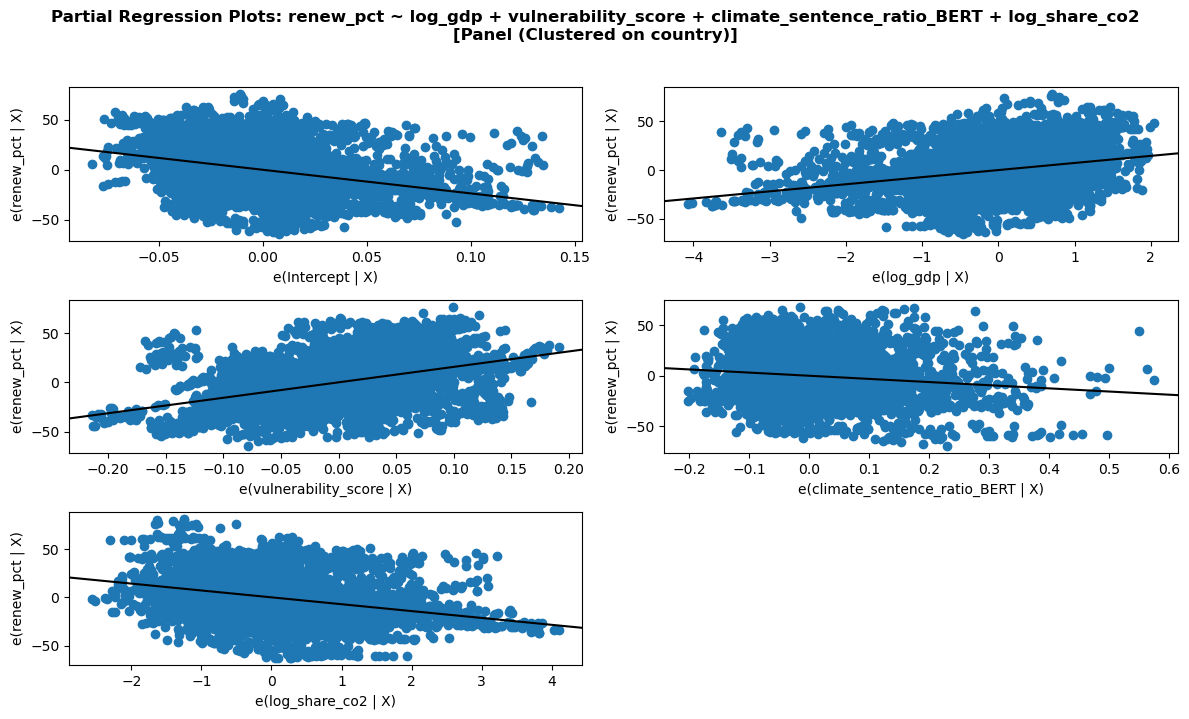

In [485]:
FEATURE_COLS = ["log_gdp", "vulnerability_score", "climate_sentence_ratio_BERT", "log_share_co2"]
TARGET_COL = "renew_pct"
correlation_matrix = preprocessed_data[FEATURE_COLS].corr()
correlation_matrix.round(3)
run_ols_regression(preprocessed_data, TARGET_COL, FEATURE_COLS, cluster_col="country", plot_=True)


# First impressions
---
log_gdp and log_share_co2 are highly correlated (.92). This is to be expected, because countries with higher GDPs have higher levels of industrialization and with that, higher levels of co2 emissions. 

Also, when looking at the effect of log_gdp and log_share_co2, their indicators are almost oppossite. That is a strong sign of multicollinearity. To adress this, we will create a new variable that is a ratio of gdp and share of co2. log_(gdp/shareco2). Note that this equals log_gdp - log_share_co2, which we see in the model aswell

We will also look at the effect of climate_sentences_BERT on log_share_co2. This is a measure of how much a country is talking about climate change in their national reports. We will see if this has an effect on their co2 emissions, controlling for gdp and vulnerability score. That way, we do not have the problem of wood burning in poor countries which counts as renewable energy.

In [493]:
preprocessed_data["log_gdp_share_co2"] = preprocessed_data["log_gdp"] - preprocessed_data["log_share_co2"]
TARGET_COL = "renew_pct"
FEATURE_COLS = ["log_gdp_share_co2", "vulnerability_score", "climate_sentences_BERT"]
run_ols_regression(preprocessed_data, TARGET_COL, FEATURE_COLS, cluster_col="country", plot_=False)


Number of rows before possibly dropping missing values: 5662
Dropped rows with missing values. Remaining rows: 4913

REGRESSION: renew_pct ~ log_gdp_share_co2 + vulnerability_score + climate_sentences_BERT
Specification: Panel (Clustered on country)
                            OLS Regression Results                            
Dep. Variable:              renew_pct   R-squared:                       0.345
Model:                            OLS   Adj. R-squared:                  0.344
Method:                 Least Squares   F-statistic:                     41.80
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           1.01e-20
Time:                        15:37:26   Log-Likelihood:                -22647.
No. Observations:                4913   AIC:                         4.530e+04
Df Residuals:                    4909   BIC:                         4.533e+04
Df Model:                           3                                         
Covariance Type:              cluster  

In [494]:
TARGET_COL = "log_share_co2"
FEATURE_COLS = ["log_gdp", "vulnerability_score", "climate_sentences_BERT"]
run_ols_regression(preprocessed_data, TARGET_COL, FEATURE_COLS, cluster_col="country", plot_=False)

Number of rows before possibly dropping missing values: 5662
Dropped rows with missing values. Remaining rows: 5046

REGRESSION: log_share_co2 ~ log_gdp + vulnerability_score + climate_sentences_BERT
Specification: Panel (Clustered on country)
                            OLS Regression Results                            
Dep. Variable:          log_share_co2   R-squared:                       0.870
Model:                            OLS   Adj. R-squared:                  0.870
Method:                 Least Squares   F-statistic:                     845.1
Date:                Fri, 25 Sep 2026   Prob (F-statistic):          1.87e-108
Time:                        15:37:33   Log-Likelihood:                -7066.6
No. Observations:                5046   AIC:                         1.414e+04
Df Residuals:                    5042   BIC:                         1.417e+04
Df Model:                           3                                         
Covariance Type:              cluster        

In [486]:
def look_forward(df_model, t_start, t_end):
    """
    Look at the effect of talking about climate change in year t on renewable energy adoption in year t+n. We cannot use shift because not every year is recorded for some countries
    """
    
    # Sort the dataframe by country and year
    df_model = df_model.sort_values(by=['country', 'year']).reset_index(drop=True)

    for t_shift in range(t_start, t_end + 1):
        df_model[f"renew_pct_t{t_shift}"] = df_model.groupby('country')['renew_pct'].shift(-t_shift)

    return df_model

def run_t_prediction(df_model, t_start, t_end, feature_cols, cluster_col="country", plot_=True):
    """
    Run OLS regression for each t in the range [t_start, t_end] to see the effect of talking about climate change in year t on renewable energy adoption in year t+n
    """
    df_model = look_forward(df_model, t_start, t_end)
    
    for n in range(t_start, t_end + 1):
        TARGET_COL = f"renew_pct_t{n}"
        print(f"\n\nLooking at the effect of talking about climate change in year t on renewable energy adoption in year t+{n}")
        run_ols_regression(df_model, TARGET_COL, feature_cols, cluster_col=cluster_col, plot_=plot_)






Looking at the effect of talking about climate change in year t on renewable energy adoption in year t+5
Number of rows before possibly dropping missing values: 5662
Dropped rows with missing values. Remaining rows: 3962

REGRESSION: renew_pct_t5 ~ climate_sentences_BERT + log_gdp_share_co2 + vulnerability_score
Specification: Panel (Clustered on country)
                            OLS Regression Results                            
Dep. Variable:           renew_pct_t5   R-squared:                       0.325
Model:                            OLS   Adj. R-squared:                  0.324
Method:                 Least Squares   F-statistic:                     36.84
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           9.39e-19
Time:                        15:26:37   Log-Likelihood:                -18246.
No. Observations:                3962   AIC:                         3.650e+04
Df Residuals:                    3958   BIC:                         3.652e+04
Df Model

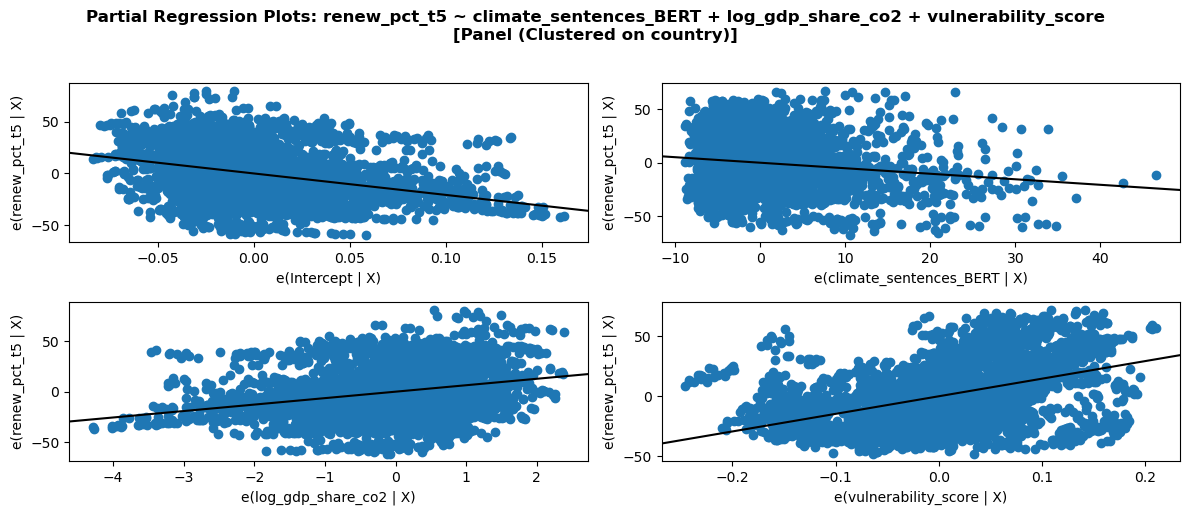

In [488]:
run_t_prediction(preprocessed_data, t_start=5, t_end=5, feature_cols=["climate_sentences_BERT", "log_gdp_share_co2", "vulnerability_score"], cluster_col="country", plot_=True)